In [18]:
import matplotlib.pyplot as py
import pandas as pd
import numpy as np
import pylab as pl

In [19]:
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML0101EN-SkillsNetwork/labs/Module%202/data/FuelConsumptionCo2.csv"
file = pd.read_csv(url)
print(file.head())

   MODELYEAR   MAKE       MODEL VEHICLECLASS  ENGINESIZE  CYLINDERS  \
0       2014  ACURA         ILX      COMPACT         2.0          4   
1       2014  ACURA         ILX      COMPACT         2.4          4   
2       2014  ACURA  ILX HYBRID      COMPACT         1.5          4   
3       2014  ACURA     MDX 4WD  SUV - SMALL         3.5          6   
4       2014  ACURA     RDX AWD  SUV - SMALL         3.5          6   

  TRANSMISSION FUELTYPE  FUELCONSUMPTION_CITY  FUELCONSUMPTION_HWY  \
0          AS5        Z                   9.9                  6.7   
1           M6        Z                  11.2                  7.7   
2          AV7        Z                   6.0                  5.8   
3          AS6        Z                  12.7                  9.1   
4          AS6        Z                  12.1                  8.7   

   FUELCONSUMPTION_COMB  FUELCONSUMPTION_COMB_MPG  CO2EMISSIONS  
0                   8.5                        33           196  
1                   

In [20]:
cdf = file[["ENGINESIZE", "CYLINDERS","FUELCONSUMPTION_CITY", "FUELCONSUMPTION_HWY", "FUELCONSUMPTION_COMB", "CO2EMISSIONS"]]
cdf.head(12)

,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,CO2EMISSIONS
0,2.0,4,9.9,6.7,8.5,196
1,2.4,4,11.2,7.7,9.6,221
2,1.5,4,6.0,5.8,5.9,136
3,3.5,6,12.7,9.1,11.1,255
4,3.5,6,12.1,8.7,10.6,244
5,3.5,6,11.9,7.7,10.0,230
6,3.5,6,11.8,8.1,10.1,232
7,3.7,6,12.8,9.0,11.1,255
8,3.7,6,13.4,9.5,11.6,267
9,2.4,4,10.6,7.5,9.2,212


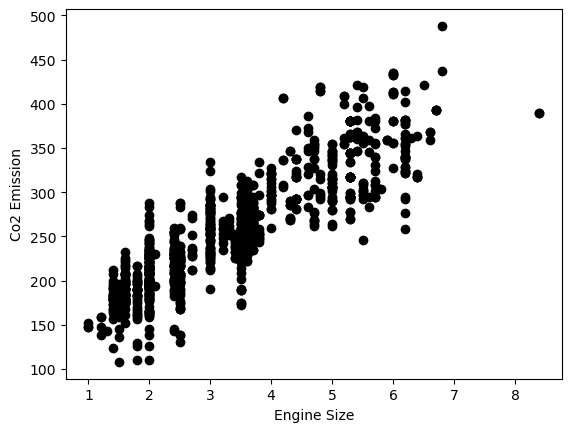

In [21]:
py.scatter(cdf.ENGINESIZE, cdf.CO2EMISSIONS, color = 'black')
py.xlabel('Engine Size')
py.ylabel('Co2 Emission')
py.show()

In [86]:
msk = np.random.rand(len(file)) < 0.8
train = cdf[msk]
test = cdf[~msk]
from sklearn import linear_model
repr = linear_model.LinearRegression()
train_x = np.asanyarray(train[['ENGINESIZE', 'FUELCONSUMPTION_COMB', 'CYLINDERS']])
train_y = np.asanyarray(train[['CO2EMISSIONS']])
repr.fit(train_x, train_y)
print('coefficient: ', repr.coef_)
print('intercept: ', repr.intercept_)
test_x = np.asanyarray(test[['ENGINESIZE', 'FUELCONSUMPTION_COMB', 'CYLINDERS']])
test_y = np.asanyarray(test[['CO2EMISSIONS']])
y_hat = repr.predict(test[['ENGINESIZE', 'FUELCONSUMPTION_COMB', 'CYLINDERS']])
print('MEAN SQUARE ERROR: %.2f' %np.mean((y_hat - test_y)**2))
print('VARIANCE: %.2f' %repr.score(test_x, test_y))

coefficient:  [[9.27984415 9.60453107 8.33966686]]
intercept:  [66.05941829]
MEAN SQUARE ERROR: 510.17
VARIANCE: 0.87


C:\Users\LAPTOP\anaconda3\lib\site-packages\sklearn\base.py:413: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(


In [87]:
train_x = np.asanyarray(train[['ENGINESIZE', 'FUELCONSUMPTION_CITY', 'FUELCONSUMPTION_HWY', 'CYLINDERS']])
train_y = np.asanyarray(train[['CO2EMISSIONS']])
repr.fit(train_x, train_y)
print('coefficient: ', repr.coef_)
print('intercept: ', repr.intercept_)
test_x = np.asanyarray(test[['ENGINESIZE', 'FUELCONSUMPTION_CITY', 'FUELCONSUMPTION_HWY', 'CYLINDERS']])
test_y = np.asanyarray(test[['CO2EMISSIONS']])
y_hat = repr.predict(test[['ENGINESIZE', 'FUELCONSUMPTION_CITY', 'FUELCONSUMPTION_HWY', 'CYLINDERS']])
print('MEAN SQUARE ERROR: %.2f' %np.mean((y_hat - test_y)**2))
print('VARIANCE: %.2f' %repr.score(test_x, test_y))

coefficient:  [[9.38652394 6.64527493 2.52678776 7.80450853]]
intercept:  [67.73619441]
MEAN SQUARE ERROR: 515.73
VARIANCE: 0.87


C:\Users\LAPTOP\anaconda3\lib\site-packages\sklearn\base.py:413: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(
